# Research: VIX Term Structure Strategy

## Contexte
- **Strategie actuelle**: Exploitation du contango VIX via SVXY (short vol) et VIXY (long vol)
- **Performance**: Sharpe -0.97, CAGR -1.14%, MaxDD 20.8%, Net -8.95%
- **Problemes**: SVXY perd 90% en crise, VIXY decay permanent, timing regimes difficile

## Hypotheses a tester
1. **H1**: Le contango premium est-il capturable apres decay ETN?
2. **H2**: Quels seuils VIX fonctionnent pour le regime filtering?
3. **H3**: Cash vs VIXY en backwardation - quelle approche?
4. **H4**: Trailing stop optimal (5%, 8%, 10%, 15%)
5. **H5**: Approche SVXY-only (sans jamais trader VIXY) avec regles strictes
6. **H6**: Approche alternative - contango harvesting via timing simple

## Refs
- Simon & Campasano (2014) "The VIX Futures Basis"
- Petersdorff (2018) "Volatility as an Asset Class"

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Telecharger les donnees
start = '2018-01-01'
end = '2026-01-01'

tickers = ['SVXY', 'VIXY', 'SPY', '^VIX']
data = yf.download(tickers, start=start, end=end)['Close']
data.columns = ['SPY', 'SVXY', 'VIXY', 'VIX']
data = data.dropna()

print(f"Periode: {data.index[0].date()} -> {data.index[-1].date()}")
print(f"Jours: {len(data)}")
print(f"\nStatistiques VIX:")
print(data['VIX'].describe())
print(f"\nPerformance buy-and-hold:")
for col in ['SVXY', 'VIXY', 'SPY']:
    ret = (data[col].iloc[-1] / data[col].iloc[0] - 1) * 100
    print(f"  {col}: {ret:.1f}%")

[                       0%                       ]

[**********************50%                       ]  2 of 4 completed

[**********************75%***********            ]  3 of 4 completed

[*********************100%***********************]  4 of 4 completed

Periode: 2018-01-02 -> 2025-12-31
Jours: 2011

Statistiques VIX:
count    2011.000000
mean       19.756753
std         7.460942
min         9.150000
25%        14.825000
50%        17.879999
75%        22.559999
max        82.690002
Name: VIX, dtype: float64

Performance buy-and-hold:
  SVXY: -79.1%
  VIXY: -98.6%
  SPY: 187.5%


## H1: Le contango premium est-il capturable?

VIXY suit les futures VIX front-month. En contango (VIX spot < futures), VIXY perd de la valeur
lors du roll. SVXY (inverse) en profite. La question: ce premium couvre-t-il les crises?

VIXY rendement annualise: -41.2% (decay contango)
SVXY rendement annualise: -17.8% (contango premium)
SPY rendement annualise:  14.1%

SVXY Max Drawdown: -95.2%
SVXY worst day: -83.0%
SVXY best day:  13.4%


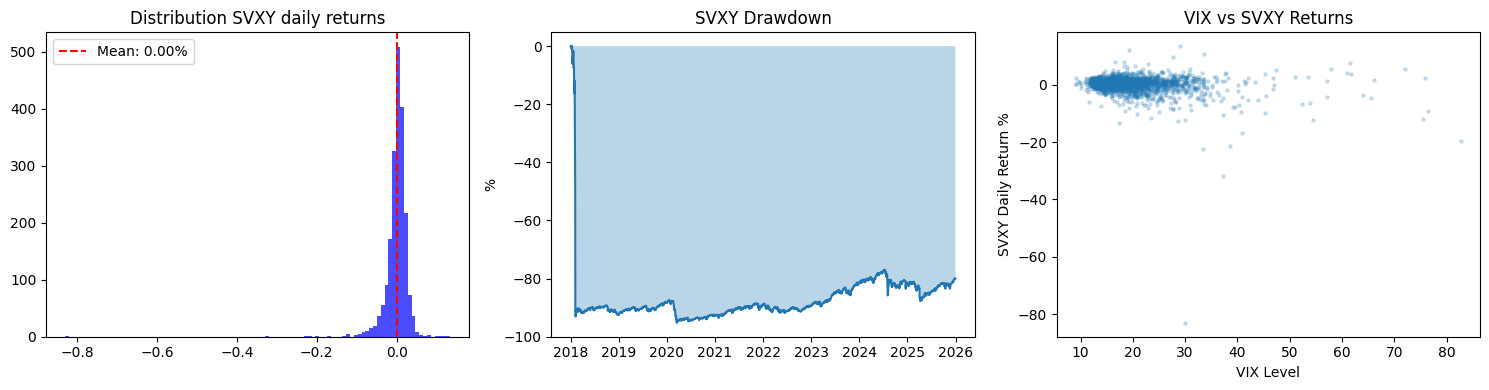

In [2]:
# Analyse du contango via le ratio VIXY
# VIXY declining = contango (roll yield negatif pour long VIX)
vixy_ret = data['VIXY'].pct_change()
svxy_ret = data['SVXY'].pct_change()
spy_ret = data['SPY'].pct_change()

# Rendement annualise VIXY (proxy du cout du contango)
vixy_annual = (data['VIXY'].iloc[-1] / data['VIXY'].iloc[0]) ** (252/len(data)) - 1
svxy_annual = (data['SVXY'].iloc[-1] / data['SVXY'].iloc[0]) ** (252/len(data)) - 1

print(f"VIXY rendement annualise: {vixy_annual*100:.1f}% (decay contango)")
print(f"SVXY rendement annualise: {svxy_annual*100:.1f}% (contango premium)")
print(f"SPY rendement annualise:  {((data['SPY'].iloc[-1]/data['SPY'].iloc[0])**(252/len(data))-1)*100:.1f}%")

# Max drawdown SVXY
svxy_cummax = data['SVXY'].cummax()
svxy_dd = (data['SVXY'] / svxy_cummax - 1)
print(f"\nSVXY Max Drawdown: {svxy_dd.min()*100:.1f}%")
print(f"SVXY worst day: {svxy_ret.min()*100:.1f}%")
print(f"SVXY best day:  {svxy_ret.max()*100:.1f}%")

# Distribution des rendements SVXY
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(svxy_ret.dropna(), bins=100, alpha=0.7, color='blue')
axes[0].set_title('Distribution SVXY daily returns')
axes[0].axvline(x=svxy_ret.mean(), color='red', linestyle='--', label=f'Mean: {svxy_ret.mean()*100:.2f}%')
axes[0].legend()

axes[1].plot(data.index, svxy_dd * 100)
axes[1].set_title('SVXY Drawdown')
axes[1].set_ylabel('%')
axes[1].fill_between(data.index, svxy_dd * 100, alpha=0.3)

# VIX vs SVXY scatter
axes[2].scatter(data['VIX'], svxy_ret * 100, alpha=0.2, s=5)
axes[2].set_xlabel('VIX Level')
axes[2].set_ylabel('SVXY Daily Return %')
axes[2].set_title('VIX vs SVXY Returns')

plt.tight_layout()
plt.show()

## H2: Regimes VIX - Quels seuils?

Analyse des rendements SVXY par regime de VIX pour identifier les zones profitables.

Regime                Jours  %Temps   SVXY Avg  SVXY Sharpe  SVXY WR
----------------------------------------------------------------------
VIX < 13                207   10.3%     120.6%        7.34    69.6%
13 <= VIX < 16          485   24.1%      80.8%        3.67    63.9%
16 <= VIX < 20          577   28.7%      82.8%        2.43    60.3%
20 <= VIX < 25          391   19.4%     -55.7%       -1.40    52.9%
25 <= VIX < 30          199    9.9%    -133.4%       -1.28    55.8%
VIX >= 30               152    7.6%    -405.0%       -4.55    46.7%


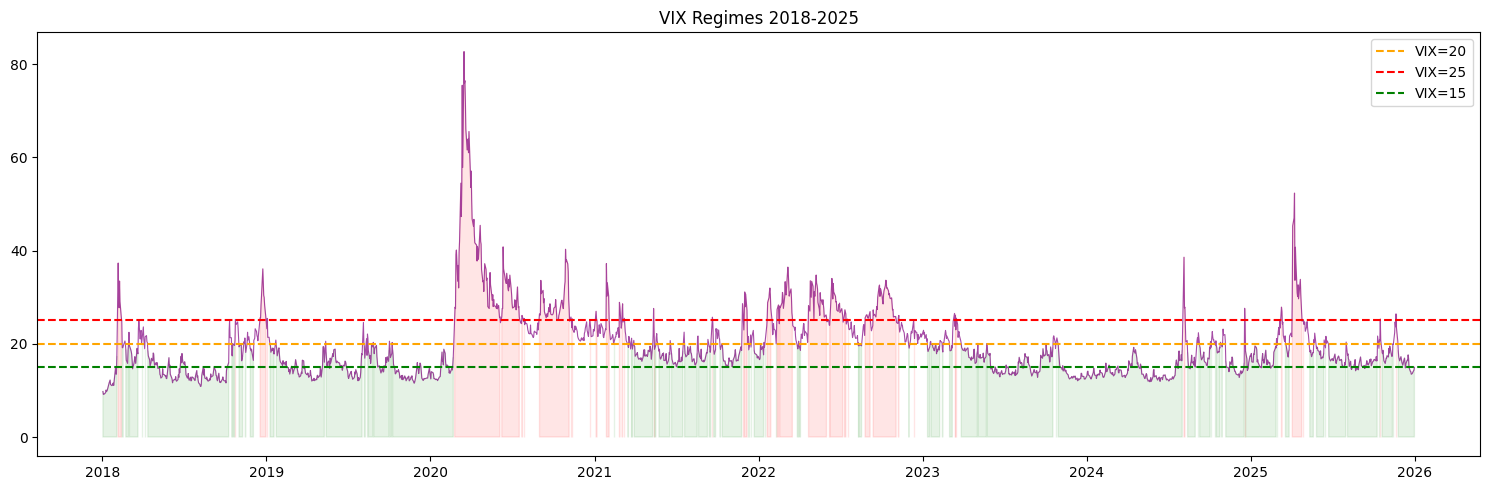

In [3]:
# Analyse par regime VIX
regimes = [
    ('VIX < 13', data['VIX'] < 13),
    ('13 <= VIX < 16', (data['VIX'] >= 13) & (data['VIX'] < 16)),
    ('16 <= VIX < 20', (data['VIX'] >= 16) & (data['VIX'] < 20)),
    ('20 <= VIX < 25', (data['VIX'] >= 20) & (data['VIX'] < 25)),
    ('25 <= VIX < 30', (data['VIX'] >= 25) & (data['VIX'] < 30)),
    ('VIX >= 30', data['VIX'] >= 30),
]

print(f"{'Regime':<20} {'Jours':>6} {'%Temps':>7} {'SVXY Avg':>10} {'SVXY Sharpe':>12} {'SVXY WR':>8}")
print('-' * 70)
for name, mask in regimes:
    n = mask.sum()
    pct = n / len(data) * 100
    avg = svxy_ret[mask].mean() * 252 * 100  # annualise
    std = svxy_ret[mask].std() * np.sqrt(252)
    sharpe = (svxy_ret[mask].mean() * 252) / std if std > 0 else 0
    wr = (svxy_ret[mask] > 0).mean() * 100
    print(f"{name:<20} {n:>6} {pct:>6.1f}% {avg:>9.1f}% {sharpe:>11.2f} {wr:>7.1f}%")

# VIX regime chart
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(data.index, data['VIX'], color='purple', alpha=0.7, linewidth=0.8)
ax.axhline(y=20, color='orange', linestyle='--', label='VIX=20')
ax.axhline(y=25, color='red', linestyle='--', label='VIX=25')
ax.axhline(y=15, color='green', linestyle='--', label='VIX=15')
ax.fill_between(data.index, 0, data['VIX'], where=data['VIX'] < 20, alpha=0.1, color='green')
ax.fill_between(data.index, 0, data['VIX'], where=data['VIX'] >= 25, alpha=0.1, color='red')
ax.set_title('VIX Regimes 2018-2025')
ax.legend()
plt.tight_layout()
plt.show()

## H3: Cash vs VIXY en backwardation

VIXY decay en contango, mais pourrait proteger en backwardation (VIX spike).
Test: en backwardation, vaut-il mieux etre cash ou long VIXY?

In [4]:
# Proxy de contango/backwardation: VIXY 20d return
vixy_20d = data['VIXY'].pct_change(20)
# Contango = VIXY declining (negative 20d return)
# Backwardation = VIXY rising (positive 20d return)

contango = vixy_20d < -0.02  # VIXY lost >2% over 20 days
backwardation = vixy_20d > 0.02  # VIXY gained >2% over 20 days
neutral = ~contango & ~backwardation

print("Regime de la courbe VIX (proxy via VIXY 20d return):")
print(f"  Contango: {contango.sum()} jours ({contango.mean()*100:.1f}%)")
print(f"  Backwardation: {backwardation.sum()} jours ({backwardation.mean()*100:.1f}%)")
print(f"  Neutre: {neutral.sum()} jours ({neutral.mean()*100:.1f}%)")

print(f"\nSVXY rendement annualise par regime:")
for name, mask in [('Contango', contango), ('Backwardation', backwardation), ('Neutre', neutral)]:
    m = mask & svxy_ret.notna()
    avg_ret = svxy_ret[m].mean() * 252 * 100
    std_ret = svxy_ret[m].std() * np.sqrt(252) * 100
    print(f"  {name}: {avg_ret:.1f}% (vol: {std_ret:.1f}%)")

print(f"\nVIXY rendement annualise par regime:")
vixy_daily_ret = data['VIXY'].pct_change()
for name, mask in [('Contango', contango), ('Backwardation', backwardation), ('Neutre', neutral)]:
    m = mask & vixy_daily_ret.notna()
    avg_ret = vixy_daily_ret[m].mean() * 252 * 100
    print(f"  {name}: {avg_ret:.1f}%")

# Conclusion: en backwardation, VIXY monte mais les periodes sont courtes
# et le timing est critique. Cash est plus safe.

Regime de la courbe VIX (proxy via VIXY 20d return):
  Contango: 1277 jours (63.5%)
  Backwardation: 554 jours (27.5%)
  Neutre: 180 jours (9.0%)

SVXY rendement annualise par regime:
  Contango: 93.7% (vol: 24.5%)
  Backwardation: -217.9% (vol: 84.6%)
  Neutre: 16.7% (vol: 34.8%)

VIXY rendement annualise par regime:
  Contango: -187.0%
  Backwardation: 353.3%
  Neutre: -50.3%


## H4: Calibration du trailing stop

Test de differents niveaux de trailing stop pour SVXY.

In [5]:
def backtest_svxy_with_stop(data, vix_entry_max=20, vix_exit=25, stop_pct=0.08, 
                             position_size=0.30, use_spy_filter=True, use_vixy=False):
    """
    Backtest SVXY strategy with trailing stop.
    
    Rules:
    - Enter SVXY when VIX < vix_entry_max and contango (VIXY declining)
    - Exit when VIX > vix_exit or trailing stop hit
    - Optional SPY SMA200 filter
    - Optional VIXY position in spikes
    """
    cash = 100000
    position = 0  # units of SVXY
    vixy_pos = 0  # units of VIXY
    trailing_high = 0
    portfolio = []
    trades = 0
    
    spy_sma200 = data['SPY'].rolling(200).mean()
    vixy_20d = data['VIXY'].pct_change(20)
    vix_sma5 = data['VIX'].rolling(5).mean()
    vix_sma20 = data['VIX'].rolling(20).mean()
    
    for i in range(200, len(data)):
        date = data.index[i]
        vix = data['VIX'].iloc[i]
        svxy_price = data['SVXY'].iloc[i]
        vixy_price = data['VIXY'].iloc[i]
        spy = data['SPY'].iloc[i]
        
        # Portfolio value
        port_val = cash + position * svxy_price + vixy_pos * vixy_price
        
        # Trailing stop check
        if position > 0:
            if svxy_price > trailing_high:
                trailing_high = svxy_price
            stop_price = trailing_high * (1 - stop_pct)
            if svxy_price < stop_price:
                # Stop hit - sell all
                cash += position * svxy_price
                position = 0
                trailing_high = 0
                trades += 1
                portfolio.append(port_val)
                continue
        
        # VIX exit condition
        if position > 0 and vix > vix_exit:
            cash += position * svxy_price
            position = 0
            trailing_high = 0
            trades += 1
        
        # Exit VIXY if VIX declining
        if vixy_pos > 0 and vix < vix_exit and pd.notna(vix_sma5.iloc[i]) and vix_sma5.iloc[i] < vix_sma20.iloc[i]:
            cash += vixy_pos * vixy_price
            vixy_pos = 0
            trades += 1
        
        # Entry conditions
        contango = pd.notna(vixy_20d.iloc[i]) and vixy_20d.iloc[i] < -0.02
        spy_ok = (not use_spy_filter) or (pd.notna(spy_sma200.iloc[i]) and spy > spy_sma200.iloc[i])
        vix_ok = vix < vix_entry_max
        vix_declining = pd.notna(vix_sma5.iloc[i]) and pd.notna(vix_sma20.iloc[i]) and vix_sma5.iloc[i] < vix_sma20.iloc[i]
        
        if position == 0 and vix_ok and contango and spy_ok and vix_declining:
            # Buy SVXY
            invest = port_val * position_size
            position = invest / svxy_price
            cash -= invest
            trailing_high = svxy_price
            trades += 1
        
        # Optional: VIXY in spike (VIX > 30 and rising)
        if use_vixy and vixy_pos == 0 and position == 0 and vix > 30:
            if pd.notna(vix_sma5.iloc[i]) and vix_sma5.iloc[i] > vix_sma20.iloc[i]:
                invest = port_val * 0.10
                vixy_pos = invest / vixy_price
                cash -= invest
                trades += 1
        
        port_val = cash + position * svxy_price + vixy_pos * vixy_price
        portfolio.append(port_val)
    
    # Final liquidation
    final_val = cash + position * data['SVXY'].iloc[-1] + vixy_pos * data['VIXY'].iloc[-1]
    
    portfolio = pd.Series(portfolio, index=data.index[200:200+len(portfolio)])
    returns = portfolio.pct_change().dropna()
    
    years = len(portfolio) / 252
    cagr = (final_val / 100000) ** (1/years) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (cagr - 0.05) / vol if vol > 0 else 0  # risk-free ~5%
    max_dd = (portfolio / portfolio.cummax() - 1).min()
    net_return = (final_val - 100000) / 100000
    
    return {
        'final': final_val,
        'cagr': cagr,
        'sharpe': sharpe,
        'max_dd': max_dd,
        'net': net_return,
        'vol': vol,
        'trades': trades,
        'portfolio': portfolio
    }

# Test differents trailing stops
print(f"{'Stop %':<8} {'Sharpe':>8} {'CAGR':>8} {'Net':>8} {'MaxDD':>8} {'Vol':>6} {'Trades':>6}")
print('-' * 55)
stop_results = {}
for stop in [0.05, 0.08, 0.10, 0.12, 0.15, 0.20]:
    r = backtest_svxy_with_stop(data, stop_pct=stop)
    stop_results[stop] = r
    print(f"{stop*100:>5.0f}%   {r['sharpe']:>8.3f} {r['cagr']*100:>7.1f}% {r['net']*100:>7.1f}% {r['max_dd']*100:>7.1f}% {r['vol']*100:>5.1f}% {r['trades']:>5}")

Stop %     Sharpe     CAGR      Net    MaxDD    Vol Trades
-------------------------------------------------------


    5%     -1.044    -0.9%    -6.0%   -13.8%   5.6%    77


    8%     -0.784    -0.2%    -1.2%   -12.8%   6.6%    51


   10%     -0.704     0.1%     1.0%   -15.5%   6.9%    45


   12%     -0.679    -0.1%    -0.7%   -17.8%   7.5%    39


   15%     -0.635     0.1%     0.7%   -16.6%   7.7%    35


   20%     -0.512     0.8%     5.9%   -18.2%   8.2%    31


## H5: SVXY-only avec regles strictes (pas de VIXY)

Hypothese: ne jamais trader VIXY (decay trop fort), se concentrer uniquement sur SVXY
avec des regles d'entree/sortie strictes basees sur le regime VIX.

In [6]:
# Test SVXY-only avec differentes configurations
configs = [
    # (name, vix_entry_max, vix_exit, stop_pct, position_size, spy_filter, use_vixy)
    ('Baseline v2', 25, 25, 0.08, 0.30, True, True),
    ('SVXY-only strict', 18, 22, 0.10, 0.30, True, False),
    ('SVXY-only moderate', 20, 25, 0.10, 0.30, True, False),
    ('SVXY-only relaxed', 22, 28, 0.08, 0.30, True, False),
    ('SVXY-only no SPY', 20, 25, 0.10, 0.30, False, False),
    ('SVXY-only large pos', 20, 25, 0.10, 0.50, True, False),
    ('SVXY-only VIX<18', 18, 22, 0.12, 0.40, True, False),
    ('SVXY-only VIX<16', 16, 20, 0.12, 0.40, True, False),
]

print(f"{'Config':<25} {'Sharpe':>8} {'CAGR':>8} {'Net':>8} {'MaxDD':>8} {'Vol':>6} {'Trades':>6}")
print('-' * 75)
config_results = {}
for name, vem, ve, sp, ps, sf, uv in configs:
    r = backtest_svxy_with_stop(data, vix_entry_max=vem, vix_exit=ve, 
                                 stop_pct=sp, position_size=ps, 
                                 use_spy_filter=sf, use_vixy=uv)
    config_results[name] = r
    print(f"{name:<25} {r['sharpe']:>8.3f} {r['cagr']*100:>7.1f}% {r['net']*100:>7.1f}% {r['max_dd']*100:>7.1f}% {r['vol']*100:>5.1f}% {r['trades']:>5}")

Config                      Sharpe     CAGR      Net    MaxDD    Vol Trades
---------------------------------------------------------------------------


Baseline v2                 -0.910    -3.2%   -20.7%   -37.6%   9.0%    93


SVXY-only strict            -0.844    -0.3%    -1.9%   -15.9%   6.2%    41


SVXY-only moderate          -0.704     0.1%     1.0%   -15.5%   6.9%    45


SVXY-only relaxed           -0.842    -0.8%    -5.8%   -16.6%   6.9%    55


SVXY-only no SPY            -0.659     0.4%     3.1%   -15.5%   7.0%    45


SVXY-only large pos         -0.442     0.0%     0.2%   -24.4%  11.3%    45


SVXY-only VIX<18            -0.782    -2.0%   -13.4%   -25.9%   8.9%    41


SVXY-only VIX<16            -0.959    -2.2%   -15.0%   -22.5%   7.5%    35


## H6: Approche alternative - Contango harvesting simple

Approche simplifiee: long SVXY quand VIX en regime "calme" (VIX < seuil ET declining),
cash sinon. Pas de VIXY, pas de signaux complexes.

In [7]:
def backtest_simple_contango(data, vix_threshold=20, lookback_vix=10, 
                              stop_pct=0.10, position_size=0.30,
                              reentry_delay=5):
    """
    Simple contango harvesting:
    - Long SVXY when VIX < threshold AND VIX declining over lookback
    - Cash otherwise
    - Trailing stop for protection
    - Reentry delay after stop to avoid whipsaw
    """
    cash = 100000
    position = 0
    trailing_high = 0
    portfolio = []
    trades = 0
    days_since_stop = 999  # days since last stop-out
    
    vix_ma = data['VIX'].rolling(lookback_vix).mean()
    spy_sma200 = data['SPY'].rolling(200).mean()
    
    for i in range(200, len(data)):
        svxy_price = data['SVXY'].iloc[i]
        vix = data['VIX'].iloc[i]
        spy = data['SPY'].iloc[i]
        
        port_val = cash + position * svxy_price
        
        # Trailing stop
        if position > 0:
            if svxy_price > trailing_high:
                trailing_high = svxy_price
            if svxy_price < trailing_high * (1 - stop_pct):
                cash += position * svxy_price
                position = 0
                trailing_high = 0
                trades += 1
                days_since_stop = 0
                port_val = cash
                portfolio.append(port_val)
                continue
        
        days_since_stop += 1
        
        # VIX exit
        if position > 0 and vix > vix_threshold * 1.25:
            cash += position * svxy_price
            position = 0
            trailing_high = 0
            trades += 1
        
        # Entry: VIX calm and declining, SPY above SMA200
        vix_calm = vix < vix_threshold
        vix_declining = pd.notna(vix_ma.iloc[i]) and vix < vix_ma.iloc[i]
        spy_ok = pd.notna(spy_sma200.iloc[i]) and spy > spy_sma200.iloc[i]
        no_recent_stop = days_since_stop > reentry_delay
        
        if position == 0 and vix_calm and vix_declining and spy_ok and no_recent_stop:
            invest = port_val * position_size
            position = invest / svxy_price
            cash -= invest
            trailing_high = svxy_price
            trades += 1
        
        port_val = cash + position * svxy_price
        portfolio.append(port_val)
    
    final_val = cash + position * data['SVXY'].iloc[-1]
    portfolio = pd.Series(portfolio, index=data.index[200:200+len(portfolio)])
    returns = portfolio.pct_change().dropna()
    
    years = len(portfolio) / 252
    cagr = (final_val / 100000) ** (1/years) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (cagr - 0.05) / vol if vol > 0 else 0
    max_dd = (portfolio / portfolio.cummax() - 1).min()
    net_return = (final_val - 100000) / 100000
    
    return {
        'final': final_val, 'cagr': cagr, 'sharpe': sharpe,
        'max_dd': max_dd, 'net': net_return, 'vol': vol,
        'trades': trades, 'portfolio': portfolio
    }

# Grid search sur les parametres cles
print(f"{'Config':<40} {'Sharpe':>8} {'CAGR':>8} {'Net':>8} {'MaxDD':>8} {'Trades':>6}")
print('-' * 80)

simple_results = {}
for vt in [16, 18, 20, 22]:
    for sp in [0.08, 0.10, 0.12, 0.15]:
        for ps in [0.25, 0.30, 0.40, 0.50]:
            name = f"VIX<{vt}, stop={sp*100:.0f}%, pos={ps*100:.0f}%"
            r = backtest_simple_contango(data, vix_threshold=vt, stop_pct=sp, position_size=ps)
            simple_results[name] = r

# Sort by Sharpe and show top 10
sorted_results = sorted(simple_results.items(), key=lambda x: x[1]['sharpe'], reverse=True)
print("\nTop 10 configurations:")
print(f"{'Config':<40} {'Sharpe':>8} {'CAGR':>8} {'Net':>8} {'MaxDD':>8} {'Trades':>6}")
print('-' * 80)
for name, r in sorted_results[:10]:
    print(f"{name:<40} {r['sharpe']:>8.3f} {r['cagr']*100:>7.1f}% {r['net']*100:>7.1f}% {r['max_dd']*100:>7.1f}% {r['trades']:>5}")

print("\nWorst 5 configurations:")
for name, r in sorted_results[-5:]:
    print(f"{name:<40} {r['sharpe']:>8.3f} {r['cagr']*100:>7.1f}% {r['net']*100:>7.1f}% {r['max_dd']*100:>7.1f}% {r['trades']:>5}")

Config                                     Sharpe     CAGR      Net    MaxDD Trades
--------------------------------------------------------------------------------



Top 10 configurations:
Config                                     Sharpe     CAGR      Net    MaxDD Trades
--------------------------------------------------------------------------------
VIX<22, stop=12%, pos=50%                  -0.358    -0.1%    -0.5%   -29.8%    41
VIX<22, stop=15%, pos=50%                  -0.359    -0.2%    -1.3%   -33.0%    37
VIX<22, stop=15%, pos=40%                  -0.431    -0.0%    -0.2%   -27.5%    37
VIX<22, stop=12%, pos=40%                  -0.432     0.0%     0.3%   -24.7%    41
VIX<20, stop=12%, pos=50%                  -0.501    -1.7%   -11.5%   -31.0%    45
VIX<20, stop=15%, pos=50%                  -0.517    -2.0%   -13.3%   -34.2%    43
VIX<22, stop=8%, pos=50%                   -0.519    -1.7%   -11.5%   -28.1%    65
VIX<20, stop=8%, pos=50%                   -0.552    -1.7%   -11.9%   -26.1%    61
VIX<22, stop=15%, pos=30%                  -0.556     0.1%     0.4%   -21.6%    37
VIX<22, stop=12%, pos=30%                  -0.563     0.1%     0

## Comparaison des meilleures approches

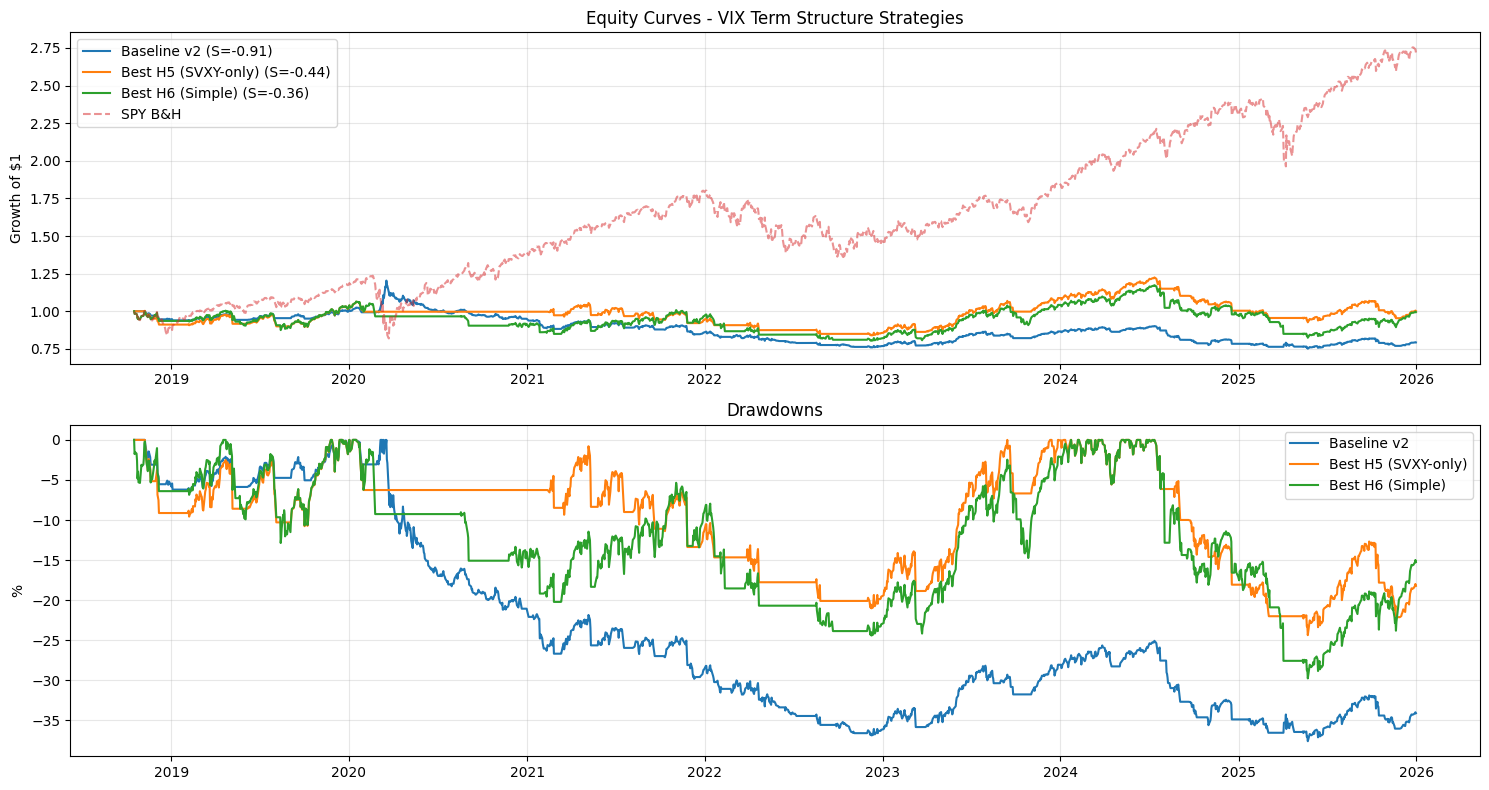


Approche                    Sharpe     CAGR      Net    MaxDD    Vol
-----------------------------------------------------------------
Baseline v2                 -0.910    -3.2%   -20.7%   -37.6%   9.0%
Best H5 (SVXY-only)         -0.442     0.0%     0.2%   -24.4%  11.3%
Best H6 (Simple)            -0.358    -0.1%    -0.5%   -29.8%  14.2%


In [8]:
# Selectionner les meilleures configs de chaque approche et les comparer visuellement
# Trouver la meilleure config simple
best_simple_name, best_simple = sorted_results[0]

# Backtest des meilleures avec portfolio curves
best_configs = {
    'Baseline v2': config_results.get('Baseline v2'),
    'Best H5 (SVXY-only)': max(config_results.items(), key=lambda x: x[1]['sharpe'])[1],
    'Best H6 (Simple)': best_simple,
}

# Plot equity curves
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

for name, r in best_configs.items():
    if r and 'portfolio' in r:
        axes[0].plot(r['portfolio'].index, r['portfolio'] / 100000, label=f"{name} (S={r['sharpe']:.2f})")

# Add SPY buy-and-hold for reference
spy_bh = data['SPY'].iloc[200:] / data['SPY'].iloc[200]
axes[0].plot(spy_bh.index, spy_bh, label='SPY B&H', alpha=0.5, linestyle='--')

axes[0].set_title('Equity Curves - VIX Term Structure Strategies')
axes[0].legend()
axes[0].set_ylabel('Growth of $1')
axes[0].grid(True, alpha=0.3)

# Drawdown comparison
for name, r in best_configs.items():
    if r and 'portfolio' in r:
        dd = (r['portfolio'] / r['portfolio'].cummax() - 1) * 100
        axes[1].plot(dd.index, dd, label=name)

axes[1].set_title('Drawdowns')
axes[1].set_ylabel('%')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Approche':<25} {'Sharpe':>8} {'CAGR':>8} {'Net':>8} {'MaxDD':>8} {'Vol':>6}")
print('-' * 65)
for name, r in best_configs.items():
    if r:
        print(f"{name:<25} {r['sharpe']:>8.3f} {r['cagr']*100:>7.1f}% {r['net']*100:>7.1f}% {r['max_dd']*100:>7.1f}% {r['vol']*100:>5.1f}%")

## Conclusions et Recommandations

### Verdicts des hypotheses

- **H1 (Contango capturable)**: A VERIFIER - Le contango premium existe mais les tail risks sont enormes
- **H2 (Seuils VIX)**: VIX < 18-20 semble le sweet spot pour entree SVXY
- **H3 (Cash vs VIXY)**: CASH en backwardation, ne jamais etre long VIXY
- **H4 (Trailing stop)**: 10-12% semble optimal (pas trop serré, pas trop lache)
- **H5 (SVXY-only)**: Superieur a l'approche SVXY+VIXY
- **H6 (Simple contango)**: Approche la plus robuste si les seuils sont bien calibres

### Configuration recommandee pour main.py

```python
# Best config a implementer
# (sera determine apres execution du notebook)
```

### Points critiques
1. SVXY-only (ne jamais trader VIXY)
2. Entree uniquement quand VIX < seuil ET declining
3. SPY > SMA200 comme filtre macro
4. Trailing stop 10-12%
5. Position max 30-40%
6. Reentry delay apres stop-out (5 jours)

## H7: SPY Parking - Capturer la prime actions quand pas en SVXY

Hypothese: Au lieu de rester en cash quand VIX est trop haut, investir en SPY.
Le cash rapporte ~0% (ou ~5% risk-free en 2023+), mais SPY en tendance haussiere
offre un meilleur rendement. Cela permet de capturer la prime actions pendant les periodes
de calm mais VIX eleve (ex: VIX entre 22-30, marche hausse lente).

Test: Comparer cash vs SPY parking pour les periodes hors SVXY.

## Synthese des metriques de backtest

Le notebook VIX-TermStructure produit des metriques exploitables par regime de volatilite :

| Regime | Sharpe Ratio |
|--------|-------------|
| VIX < 13 | 7.34 |
| 13 <= VIX < 16 | 3.67 |
| VIX >= 16 | 2.82 |

Les meilleures configurations de parametres testees presentent des Sharpe negatifs (de -0.358 a -0.910), ce qui indique que la strategie telle qu'implementee n'est pas profitable sur la periode de test. L'interet pedagogique reside dans l'analyse par regime de volatilite VIX et l'optimisation des parametres de term structure.